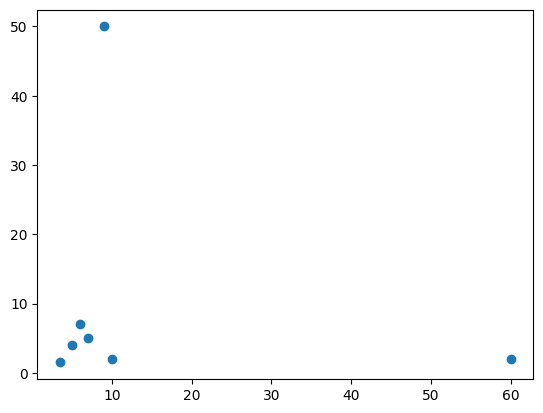

In [2]:
import matplotlib.pyplot as plt

values = (6, 9, 7, 10, 3.50, 60, 5)
bids = (7, 50, 4.99, 2, 1.50, 2, 4)

plt.figure()
plt.scatter(values, bids)

In [3]:
import scipy.stats

N = 10
valuation_distributions = [scipy.stats.uniform for _ in range(N)]
valuation_distributions

In [4]:
import sold.bid
bidding_functions = [sold.bid.create_shaded_bid_map((i + 1) / N) for i in range(N - 1)] + [sold.bid.true_value]
bidding_functions

[<function sold.bid.create_shaded_bid_map.<locals>.bid_map(value)>,
 <function sold.bid.create_shaded_bid_map.<locals>.bid_map(value)>,
 <function sold.bid.create_shaded_bid_map.<locals>.bid_map(value)>,
 <function sold.bid.create_shaded_bid_map.<locals>.bid_map(value)>,
 <function sold.bid.create_shaded_bid_map.<locals>.bid_map(value)>,
 <function sold.bid.create_shaded_bid_map.<locals>.bid_map(value)>,
 <function sold.bid.create_shaded_bid_map.<locals>.bid_map(value)>,
 <function sold.bid.create_shaded_bid_map.<locals>.bid_map(value)>,
 <function sold.bid.create_shaded_bid_map.<locals>.bid_map(value)>,
 <function sold.bid.true_value(value)>]

In [5]:
import sold.allocate
import sold.pay
allocation_rule = sold.allocate.first_price
payment_rule = sold.pay.second_price

In [6]:
import sold
seed = 0
allocation, payments, valuations = sold.auction(
    valuation_distributions=valuation_distributions,
    bidding_functions=bidding_functions,
    allocation_rule=allocation_rule,
    payment_rule=payment_rule,
    seed=seed,
)
allocation

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])

In [7]:
import numpy as np
repetitions = 10_000
utility = np.zeros(N)
for seed in range(repetitions):
    allocation, payments, valuations = sold.auction(
        valuation_distributions=valuation_distributions,
        bidding_functions=bidding_functions,
        allocation_rule=allocation_rule,
        payment_rule=payment_rule,
        seed=seed,
    )
    utility += allocation * valuations - payments
utility /= repetitions
utility

array([0.        , 0.        , 0.00019114, 0.00252914, 0.00717527,
       0.02088046, 0.03997725, 0.05441776, 0.07010232, 0.07945485])

In [8]:
import nashpy as nash
import numpy as np

In [15]:
M_r = np.array(
    (
        (3, 1),
        (2, 2),
    )
)
M_c = np.array(
    (
        (3, 4),
        (5, 1),
    )
)
game = nash.Game(M_r, M_c)
tuple(game.support_enumeration())

((array([0.8, 0.2]), array([0.5, 0.5])),)

In [61]:
import sympy as sym

x_p = sym.Symbol("x_P")
y_h = sym.Symbol("y_H")

M_r = sym.Matrix(M_r)
M_c = sym.Matrix(M_c)

In [62]:
f_p, f_r = M_r * sym.Matrix((y_h, 1 - y_h))
f_p

2*y_H + 1

In [63]:
f_r

2

In [64]:
f_h, f_b = sym.Matrix((x_p, 1 - x_p)).T  * M_c
f_b

3*x_P + 1

In [65]:
f_b

3*x_P + 1

In [66]:
M_c

Matrix([
[3, 4],
[5, 1]])

In [67]:
sym.Matrix((x_p, 1 - x_p)).T * M_c

Matrix([[5 - 2*x_P, 3*x_P + 1]])

In [68]:
phi_x = (sym.Matrix([x_p, 1 - x_p]).T * M_r * sym.Matrix((y_h, 1 - y_h)))[0]
sym.expand(phi_x)

2*x_P*y_H - x_P + 2

In [69]:
phi_y = (sym.Matrix((x_p, 1 - x_p)).T * M_c * sym.Matrix((y_h, 1 - y_h)))[0]
sym.expand(phi_y)

-5*x_P*y_H + 3*x_P + 4*y_H + 1

In [70]:
dx_p = x_p * (f_p - phi_x)
sym.expand(dx_p)

-2*x_P**2*y_H + x_P**2 + 2*x_P*y_H - x_P

In [71]:
dy_h = y_h * (f_h - phi_y)
sym.expand(dy_h)

5*x_P*y_H**2 - 5*x_P*y_H - 4*y_H**2 + 4*y_H

In [74]:
dx_p.subs({x_p: sym.S(4)/5, y_h: sym.S(1) / 2})

0

In [75]:
dy_h.subs({x_p: sym.S(4)/5, y_h: sym.S(1) / 2})

0

In [76]:
sym.latex(sym.expand(dx_p))

'- 2 x_{P}^{2} y_{H} + x_{P}^{2} + 2 x_{P} y_{H} - x_{P}'

In [77]:
sym.latex(sym.expand(dy_h))

'5 x_{P} y_{H}^{2} - 5 x_{P} y_{H} - 4 y_{H}^{2} + 4 y_{H}'